# HR Analytics — Previsão de Saída de Funcionários (Employee Churn)

Este projeto analisa uma base com características de colaboradores de uma empresa — nível de satisfação, horas mensais trabalhadas, tempo de casa, histórico de acidentes de trabalho, departamento, faixa salarial, entre outros — com o objetivo de entender os fatores associados à saída voluntária (`left`) e construir um modelo preditivo de churn.

O fluxo do projeto segue quatro etapas: (1) validação e tratamento dos dados, (2) análise exploratória, (3) teste de hipótese estatística sobre um dos padrões observados, e (4) construção e validação de um modelo de classificação.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

## 1. Validação e tratamento dos dados

Antes de qualquer análise, validei a consistência da base: valores nulos, duplicados e outliers, além de uma primeira leitura estatística descritiva das variáveis.


In [2]:
df = pd.read_csv('HR_Abandono.csv', sep = ';', decimal=',')

In [3]:
df.head()

,id,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,num_project,depto
0,1,0.38,0.53,157,3,0,1,0,low,2,sales
1,2,0.80,0.86,262,6,0,1,0,medium,5,sales
2,3,0.11,0.88,272,4,0,1,0,medium,6,sales
3,4,0.72,0.87,223,5,0,1,0,low,5,sales
4,5,0.37,0.52,159,3,0,1,0,low,2,sales


In [4]:
df['depto'].unique()

<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

In [5]:
siglas = {'sales' : 'sales', 'accounting' : 'acc', 'hr' : 'hr', 'technical' : 'tech', 'support' : 'sup', 'management' : 'man',
          'IT' : 'it', 'product_mng' : 'prod', 'marketing' : 'mkt', 'RandD' : 'rand'}
df['depto'] = df['depto'].replace(siglas)

In [6]:
df.drop('id', axis=1, inplace=True)

In [7]:
df.shape

(14999, 10)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   average_montly_hours   14999 non-null  int64  
 3   time_spend_company     14999 non-null  int64  
 4   Work_accident          14999 non-null  int64  
 5   left                   14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
 7   salary                 14999 non-null  str    
 8   num_project            14999 non-null  int64  
 9   depto                  14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [9]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
salary                   0
num_project              0
depto                    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(3005)

In [11]:
df['salary'].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

In [12]:
df['depto'].unique()

<StringArray>
['sales', 'acc', 'hr', 'tech', 'sup', 'man', 'it', 'prod', 'mkt', 'rand']
Length: 10, dtype: str

In [13]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
       'salary', 'num_project', 'depto'],
      dtype='str')

<Axes: xlabel='average_montly_hours'>

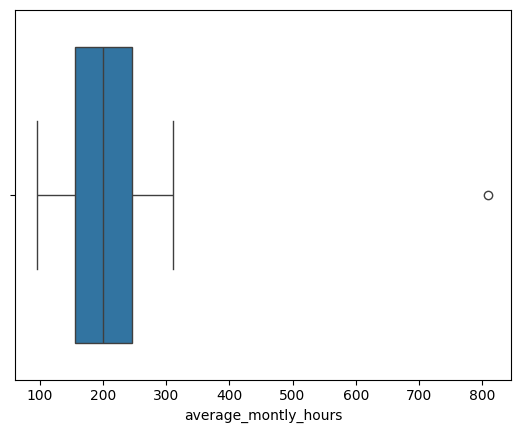

In [14]:
sns.boxplot(data=df, x='average_montly_hours')

In [15]:
df['average_montly_hours'].value_counts().head(20)

average_montly_hours
135    153
156    153
149    148
151    147
160    136
145    134
140    129
143    127
157    126
257    126
155    125
158    124
260    124
245    124
148    123
153    122
137    122
159    121
154    121
139    120
Name: count, dtype: int64

In [16]:
df['average_montly_hours'].value_counts()[310]

np.int64(17)

In [17]:
df.loc[df['average_montly_hours'] == 810, 'average_montly_hours'] = 310

<Axes: xlabel='average_montly_hours'>

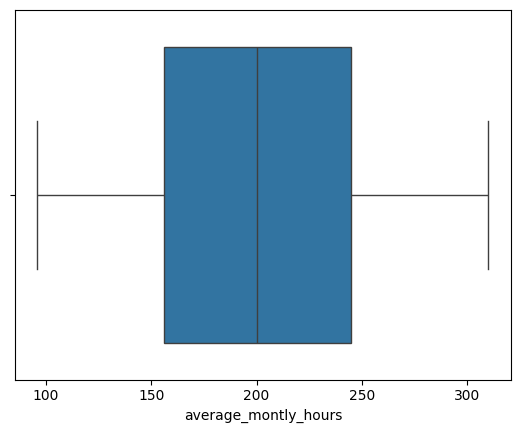

In [18]:
sns.boxplot(data=df, x='average_montly_hours')

<Axes: xlabel='time_spend_company'>

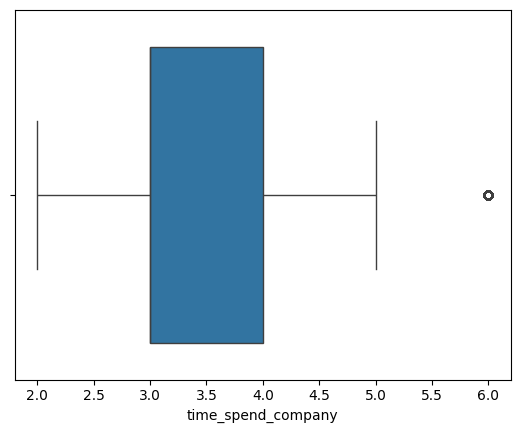

In [19]:
sns.boxplot(data=df, x='time_spend_company')

In [20]:
df['time_spend_company'].value_counts()

time_spend_company
3    6443
2    3244
4    2557
5    1473
6    1282
Name: count, dtype: int64

<Axes: xlabel='left'>

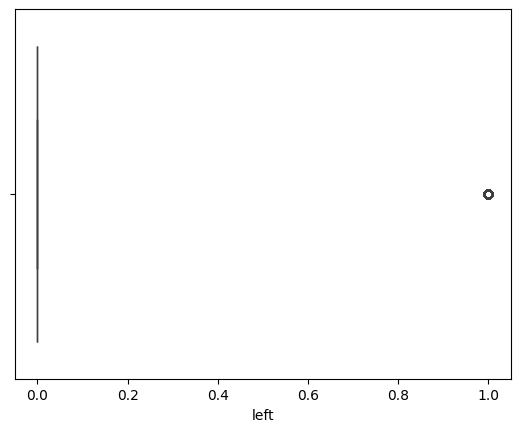

In [21]:
sns.boxplot(data=df, x='left')

In [22]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

<Axes: xlabel='promotion_last_5years'>

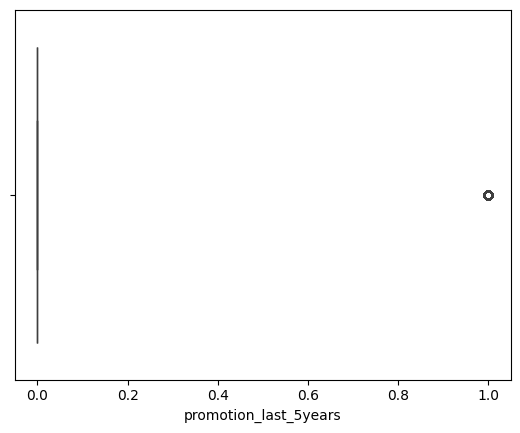

In [23]:
sns.boxplot(data=df, x='promotion_last_5years')

In [24]:
df['promotion_last_5years'].value_counts()

promotion_last_5years
0    14680
1      319
Name: count, dtype: int64

In [25]:
df.describe()

,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,num_project
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612823,0.716102,201.050337,3.407027,0.144610,0.238083,0.021268,3.785986
std,0.248655,0.171169,49.943099,1.176120,0.351719,0.425924,0.144281,1.194539
min,0.010000,0.360000,96.000000,2.000000,0.000000,0.000000,0.000000,2.000000
25%,0.440000,0.560000,156.000000,3.000000,0.000000,0.000000,0.000000,3.000000
50%,0.640000,0.720000,200.000000,3.000000,0.000000,0.000000,0.000000,4.000000
75%,0.820000,0.870000,245.000000,4.000000,0.000000,0.000000,0.000000,5.000000
max,1.000000,1.000000,310.000000,6.000000,1.000000,1.000000,1.000000,6.000000


In [26]:
df['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [27]:
df['depto'].value_counts()

depto
sales    4140
tech     2720
sup      2229
it       1227
prod      902
mkt       858
rand      787
acc       767
hr        739
man       630
Name: count, dtype: int64

## 2. Análise exploratória

Explorei as relações entre as variáveis e a saída de funcionários (`left`), buscando padrões que expliquem por que colaboradores deixam a empresa.


<Axes: xlabel='satisfaction_level', ylabel='last_evaluation'>

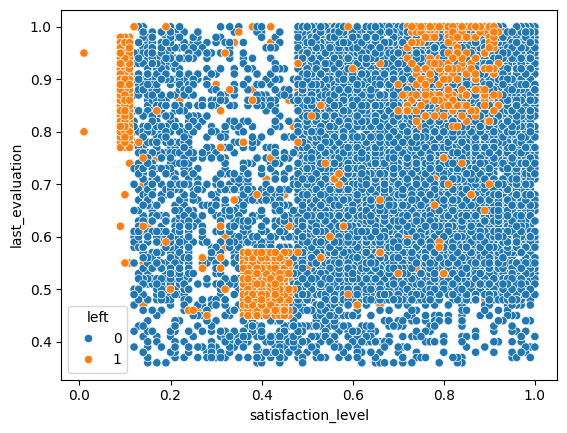

In [28]:
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left')

Entre quem saiu da empresa, existem dois perfis bem distintos e opostos: um grupo com **satisfação baixa e avaliação alta** (colaboradores bons, mas insatisfeitos — provável risco de burnout) e outro com **satisfação alta e avaliação alta** (bons colaboradores satisfeitos que mesmo assim saíram — possivelmente atraídos por oportunidades externas). Ou seja, uma nota de avaliação alta sozinha não indica quem vai ficar.

<Axes: xlabel='satisfaction_level', ylabel='average_montly_hours'>

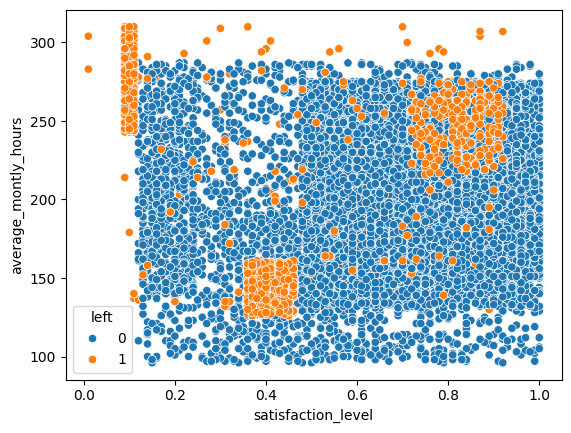

In [29]:
sns.scatterplot(data=df, x='satisfaction_level', y='average_montly_hours', hue='left')

Quem saiu tem satisfação média bem mais baixa (0,44 vs. 0,67 de quem ficou), mas a diferença de horas trabalhadas é pequena (207h vs. 199h). Isso sugere que a insatisfação em si pesa mais na saída do que a carga horária isolada.

<Axes: xlabel='time_spend_company', ylabel='satisfaction_level'>

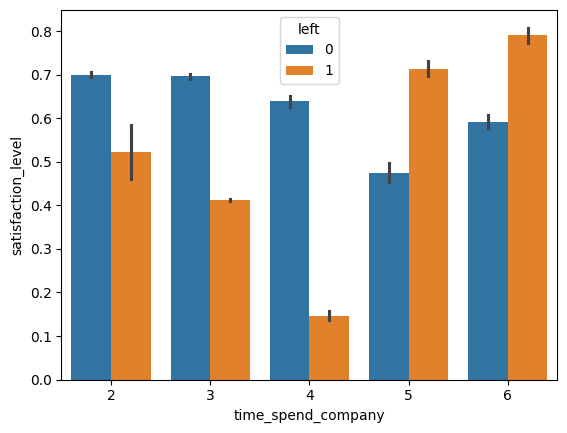

In [30]:
sns.barplot(data=df, x='time_spend_company', y='satisfaction_level', hue='left')

Entre quem saiu, a satisfação despenca aos 4 anos de empresa (0,15, o ponto mais baixo de toda a série) e depois sobe de novo aos 5-6 anos (acima de 0,70). Isso indica dois motivos de saída diferentes: um grupo que sai infeliz e relativamente cedo, e outro que sai satisfeito depois de mais tempo de casa — provavelmente por motivos externos (nova oportunidade), não por insatisfação.

<Axes: xlabel='num_project', ylabel='satisfaction_level'>

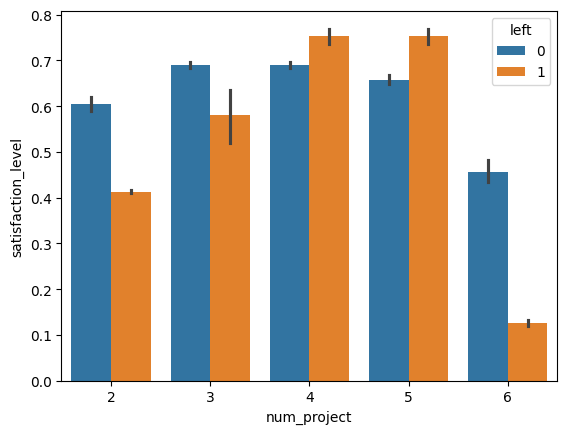

In [31]:
sns.barplot(data=df, x='num_project', y='satisfaction_level', hue='left')

Entre quem saiu, a satisfação cai nos dois extremos de carga de projetos: com apenas 2 projetos (0,41) e com 6 projetos (0,13, o menor valor do gráfico). Poucos projetos parece indicar subutilização; muitos projetos, sobrecarga. Os dois formam o mesmo problema por caminhos opostos: falta de encaixe entre carga de trabalho e a pessoa.

<Axes: xlabel='last_evaluation', ylabel='average_montly_hours'>

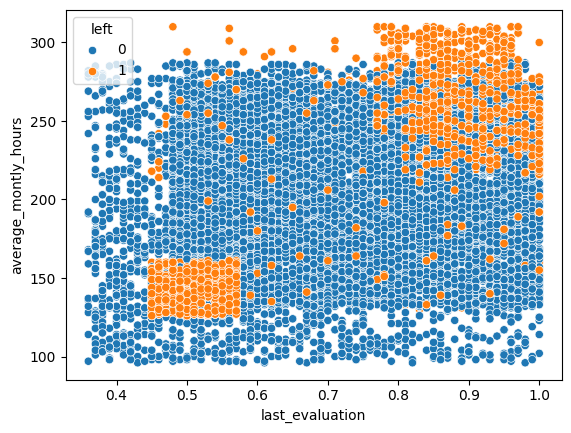

In [32]:
sns.scatterplot(data=df, x='last_evaluation', y='average_montly_hours', hue='left')

Existe uma correlação positiva, mas moderada (0,34), entre horas trabalhadas e nota de avaliação — trabalhar mais está associado a notas um pouco melhores, mas está longe de ser o fator dominante.

<Axes: xlabel='time_spend_company', ylabel='last_evaluation'>

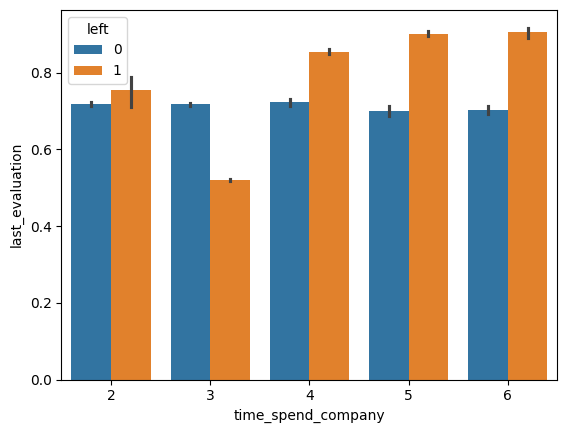

In [33]:
sns.barplot(data=df, x='time_spend_company', y='last_evaluation', hue='left')

<Axes: xlabel='time_spend_company', ylabel='average_montly_hours'>

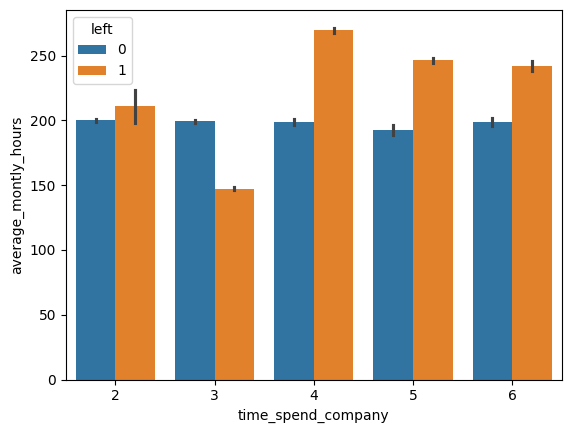

In [34]:
sns.barplot(data=df, x='time_spend_company', y='average_montly_hours', hue='left')

Estes dois gráficos juntos contam a mesma história por ângulos diferentes: entre quem saiu, tanto a nota de avaliação (de 0,75 aos 2 anos para 0,90 aos 6 anos) quanto as horas trabalhadas (de 211h para 242h) sobem com o tempo de casa. Ou seja, a empresa está perdendo justamente os funcionários mais experientes, mais bem avaliados e mais sobrecarregados — o perfil mais caro de se perder.

<Axes: xlabel='num_project', ylabel='average_montly_hours'>

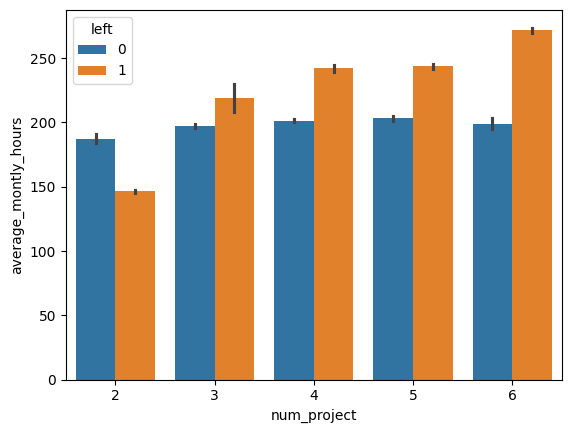

In [35]:
sns.barplot(data=df, x='num_project', y='average_montly_hours', hue='left')

O mesmo padrão de sobrecarga aparece aqui: entre quem saiu e tinha 6 projetos, a média de horas mensais chega a 272h, bem acima das 199h de quem ficou com a mesma carga de projetos — reforçando que excesso de projetos está associado tanto a mais horas quanto a maior saída.

<Axes: xlabel='salary', ylabel='time_spend_company'>

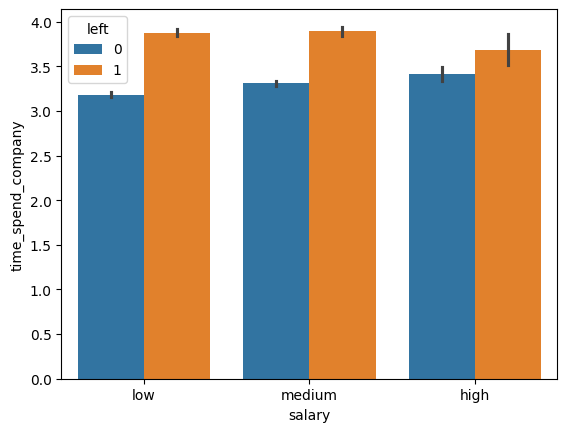

In [36]:
sns.barplot(data=df, x='salary', y='time_spend_company', hue='left')

O tempo de casa por faixa salarial varia pouco entre quem ficou e quem saiu, mas a faixa salarial em si é um dos fatores mais fortes associados à saída: a taxa de churn é de **29,7% entre salários baixos**, cai para 20,4% em salários médios e despenca para **6,6% em salários altos**. A chance de promoção segue o mesmo padrão (0,9% para salário baixo vs. 5,8% para salário alto) — o que sugere um problema de teto de carreira concentrado justamente em quem ganha menos.

<Axes: xlabel='depto', ylabel='promotion_last_5years'>

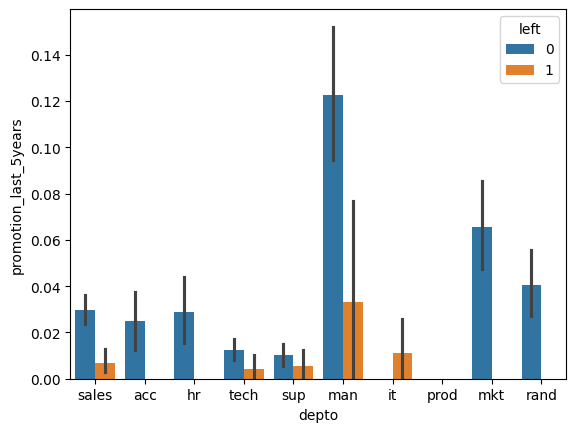

In [37]:
sns.barplot(data=df, x='depto', y='promotion_last_5years', hue='left')

Departamentos com mais promoções tendem a reter mais gente: Management tem a maior taxa de promoção (11%) e a menor taxa de churn (14%); HR tem a menor taxa de promoção (2%) e a maior taxa de churn (29%). É um indício de que a falta de perspectiva de crescimento, não só o salário, ajuda a explicar a saída.

## 3. Teste de hipótese

Um padrão que chamou atenção na análise exploratória foi a relação entre faixa salarial e carga horária mensal. Testei formalmente a hipótese de que colaboradores com salário baixo trabalham, em média, mais horas por mês do que colaboradores com salário médio ou alto.


In [38]:
low = df[df['salary'] == 'low']
medium = df[df['salary'] == 'medium']
high = df[df['salary'] == 'high']


In [39]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
       'salary', 'num_project', 'depto'],
      dtype='str')

<Axes: xlabel='average_montly_hours', ylabel='Count'>

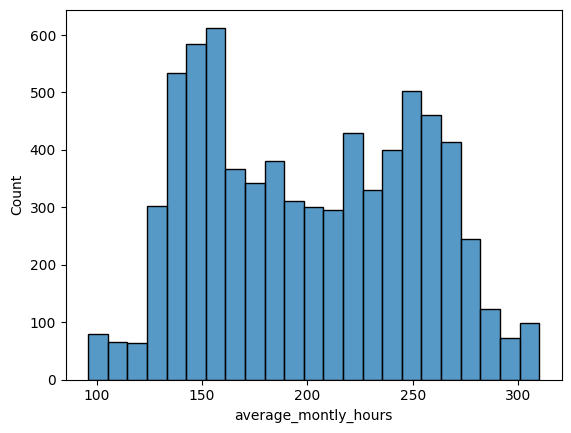

In [40]:
sns.histplot(data = low['average_montly_hours'])

<Axes: xlabel='average_montly_hours', ylabel='Count'>

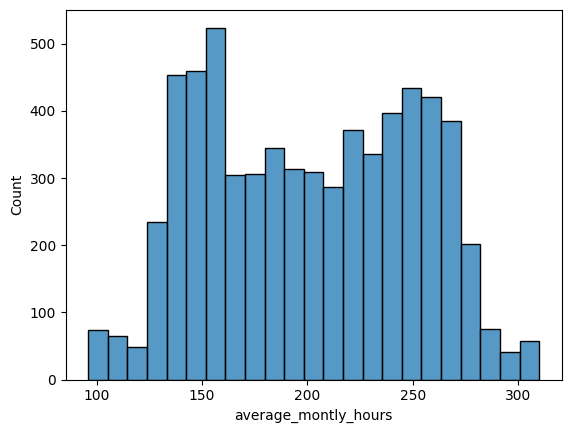

In [41]:
sns.histplot(data = medium['average_montly_hours'])

<Axes: xlabel='average_montly_hours', ylabel='Count'>

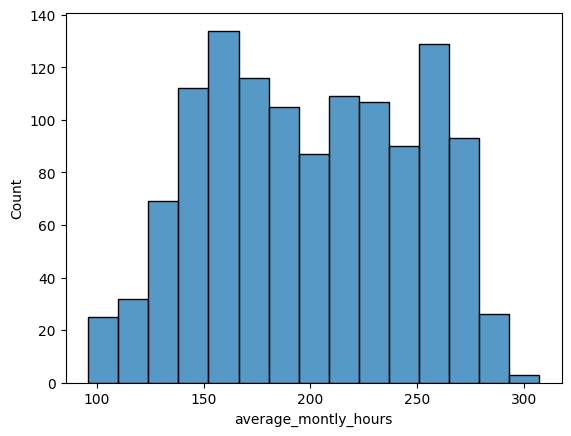

In [42]:
sns.histplot(data = high['average_montly_hours'])

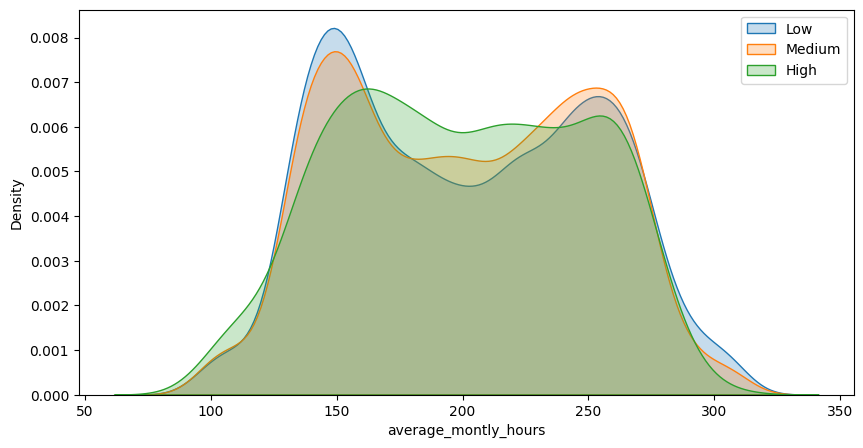

In [43]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=low['average_montly_hours'], label='Low', fill=True)
sns.kdeplot(data=medium['average_montly_hours'], label='Medium', fill=True)
sns.kdeplot(data=high['average_montly_hours'], label='High', fill=True)
plt.legend()

In [44]:
stat, p = shapiro(low['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9599, valor p: 6.987004491004302e-41
A hipótese de normalidade é rejeitada.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7316.
  res = hypotest_fun_out(*samples, **kwds)


In [45]:
stat, p = shapiro(medium['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9642, valor p: 3.21700299150534e-37
A hipótese de normalidade é rejeitada.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6446.
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
stat, p = shapiro(high['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9712, valor p: 5.6027314672963646e-15
A hipótese de normalidade é rejeitada.


In [47]:
stat, p = mannwhitneyu(low['average_montly_hours'].sample(len(low['average_montly_hours'])),
                       medium['average_montly_hours'].sample(len(medium['average_montly_hours'])),  alternative='greater')

print('Estatística de teste U: ', stat)
print('Valor p: ', p)

alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')

Estatística de teste U:  23437165.5
Valor p:  0.7296955301554764
Não há diferença estatisticamente significante


In [48]:
stat, p = mannwhitneyu(low['average_montly_hours'].sample(len(low['average_montly_hours'])),
                       high['average_montly_hours'].sample(len(high['average_montly_hours'])),  alternative='greater')

print('Estatística de teste U: ', stat)
print('Valor p: ', p)

alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')

Estatística de teste U:  4542795.5
Valor p:  0.41206653604293464
Não há diferença estatisticamente significante


## 4. Definição do problema

O objetivo é prever se um colaborador vai deixar a empresa (`left`) a partir das demais variáveis — um problema de classificação binária supervisionada.


In [49]:
df = pd.get_dummies(df, columns=['salary'])
df[[col for col in df.columns if col.startswith('salary_')]] = df[[col for col in df.columns if col.startswith('salary_')]].astype(int)

In [50]:
x = df.drop(columns=['left', 'depto'])
y = df['left'] #target

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
# Padronização das variáveis: KNN é um algoritmo baseado em distância,
# então features em escalas muito diferentes (ex.: satisfaction_level entre 0-1
# vs. average_montly_hours na casa de centenas) distorceriam o cálculo de distância
# se não fossem colocadas na mesma escala.
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)


## 5. Construção do modelo

Antes de treinar o modelo final, testei três algoritmos (KNN, SVM e Random Forest) via validação cruzada, usando apenas os dados de treino padronizados. A base é desbalanceada (a classe `left=1` é minoritária), então também apliquei SMOTE — somente sobre o conjunto de treino, para não vazar informação do conjunto de teste — antes de treinar o modelo escolhido.


In [52]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [53]:
oversample = SMOTE(random_state=42)
x_train_os, y_train_os = oversample.fit_resample(x_train_scaled, y_train)


In [54]:
error = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scaled, y_train)
    pred_i = knn.predict(x_test_scaled)
    error.append(np.mean(pred_i != y_test))


Text(0, 0.5, 'Mean Error')

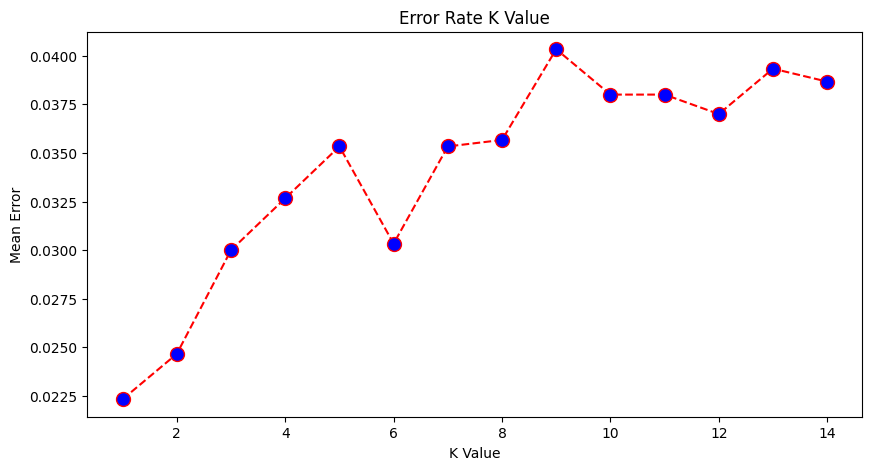

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [56]:
def AplicaValidacaoCruzada(x_axis, y_axis):

  kfold  = KFold(n_splits=10, shuffle=True)

  x = x_axis
  y = y_axis

  # KNN
  knn = KNeighborsClassifier(n_neighbors=2, metric= 'euclidean', weights='distance')
  knn.fit(x, y)

  # SVM
  svm = SVC()
  svm.fit(x, y)

  # RandomForest
  rf = RandomForestClassifier(random_state=7)
  rf.fit(x, y)

  # KFold
  knn_result = cross_val_score(knn, x, y, cv = kfold)
  svm_result = cross_val_score(svm, x, y, cv = kfold)
  rf_result = cross_val_score(rf, x, y, cv = kfold)

  dic_models = {
    "KNN": knn_result.mean(),
    "SVM": svm_result.mean(),
    "RF": rf_result.mean()
  }

  melhorModelo = max(dic_models, key=dic_models.get)

  print("KNN (R^2): {0}\nSVM (R^2): {1}\nRandom Forest (R^2): {2}".format(knn_result.mean(), svm_result.mean(), rf_result.mean()))
  print("O melhor modelo é : {0} com o valor: {1}".format(melhorModelo, dic_models[melhorModelo]))

In [57]:
AplicaValidacaoCruzada(x_train_scaled, y_train)


KNN (R^2): 0.9732478454267446
SVM (R^2): 0.9597455518487628
Random Forest (R^2): 0.9907493049763693
O melhor modelo é : RF com o valor: 0.9907493049763693


In [58]:
param_grid = {'n_neighbors':[2, 3],
              'weights': ['uniform', 'distance'],
              'metric':['cosine', 'euclidean', 'manhattan'],
             }

gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid,
                    scoring=gs_metric,
                    cv=5, n_jobs=1, verbose=0)

grid.fit(x_train_os, y_train_os)
knn_params = grid.best_params_
print('Melhores hiperparâmetros (KNN):', knn_params)


Melhores hiperparâmetros (KNN): {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'}


In [59]:
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine', weights='distance')
scores = cross_val_score(knn, x_train_os, y_train_os, cv=5)

print("Acurácias por fold:", scores)
print("Acurácia média:", scores.mean())


Acurácias por fold: [0.97101449 0.97511622 0.97593656 0.97621001 0.97702407]
Acurácia média: 0.9750602692955986


In [60]:
knn.fit(x_train_os, y_train_os)
y_predito = knn.predict(x_test_scaled)


## 6. Validação do modelo

Avaliei o modelo no conjunto de teste (nunca visto durante o treino), usando matriz de confusão, relatório de classificação e curva ROC.


<Figure size 1500x500 with 0 Axes>

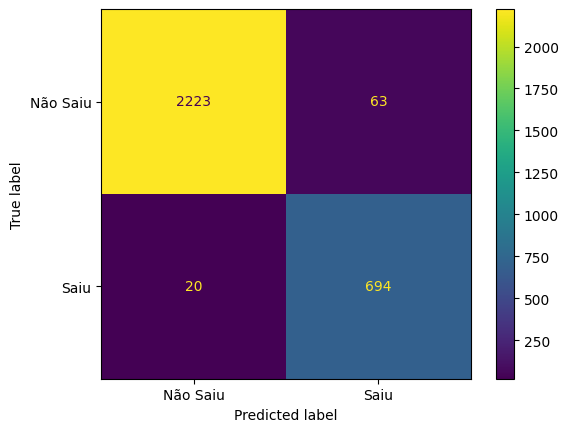

In [61]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predito,
                                   labels=[0,1])

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao,
                              display_labels=['Não Saiu', 'Saiu'])
disp.plot(values_format='d')

In [62]:
print(classification_report(y_test, y_predito))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2286
           1       0.92      0.97      0.94       714

    accuracy                           0.97      3000
   macro avg       0.95      0.97      0.96      3000
weighted avg       0.97      0.97      0.97      3000



In [63]:
y_prob = knn.predict_proba(x_test_scaled)[:,1]


In [64]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

0.9794645767318301

Text(0.5, 0, 'False Positive Rate')

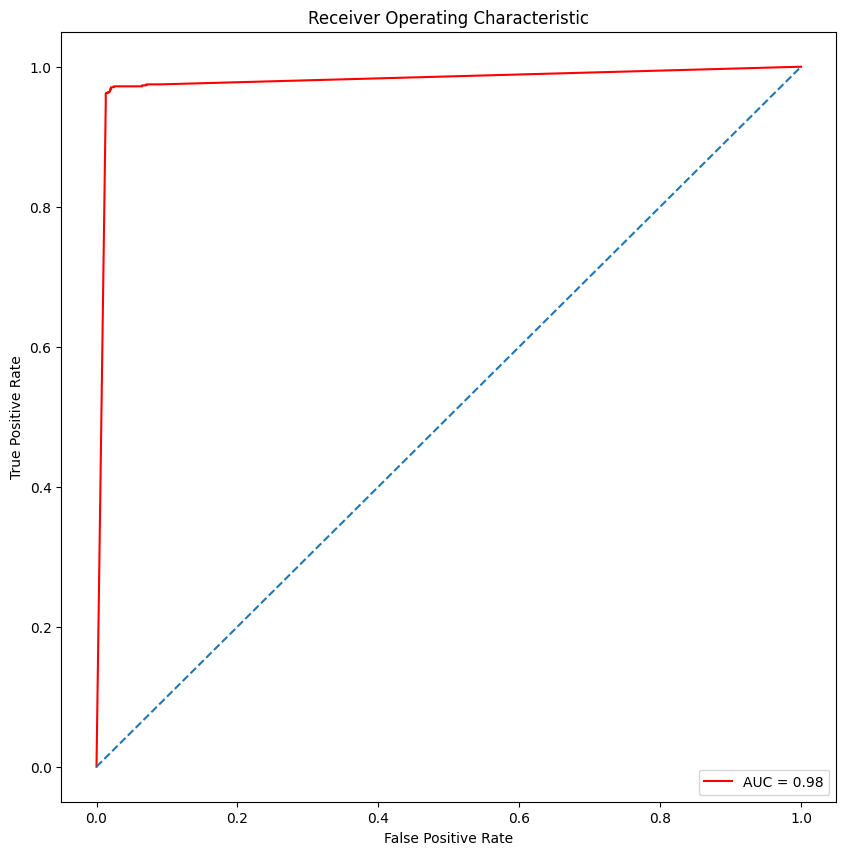

In [65]:
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')